In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from itertools import permutations
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = 'cannibalization_output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

BRAND_COLOR = {
    'Richeese': '#378ADD',
    'Richoco':  '#D4537E',
    'Nextar':   '#1D9E75',
}

CAT_COLOR = {
    'Wafer':          '#378ADD',
    'Kue/Pie':        '#1D9E75',
    'Minuman':        '#D4537E',
    'Mi Instan':      '#BA7517',
    'Extruded Snack': '#534AB7',
    'Biskuit':        '#888780',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
})

print('✅ Config selesai')


✅ Config selesai


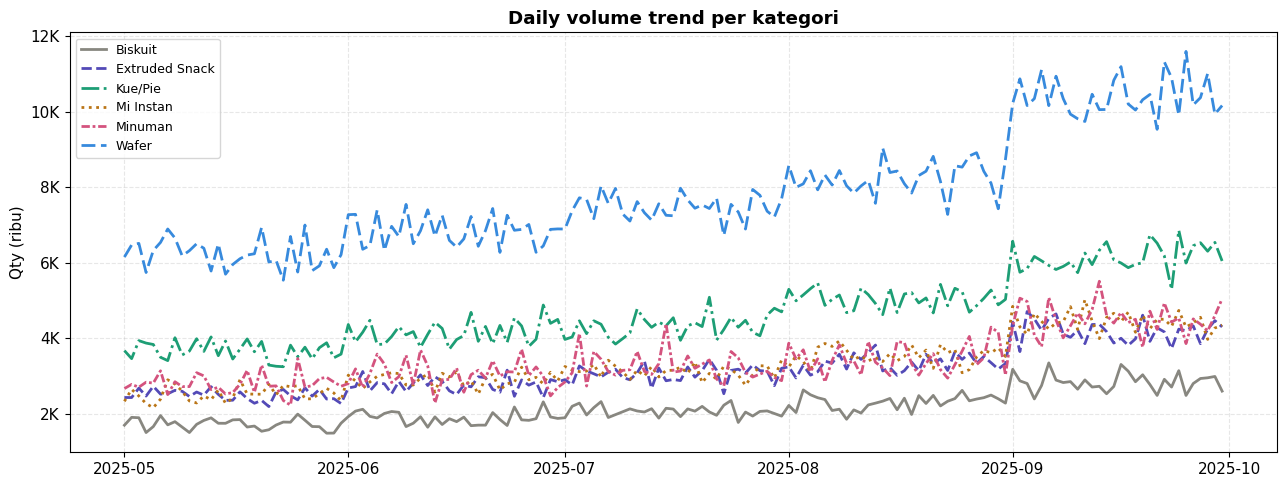

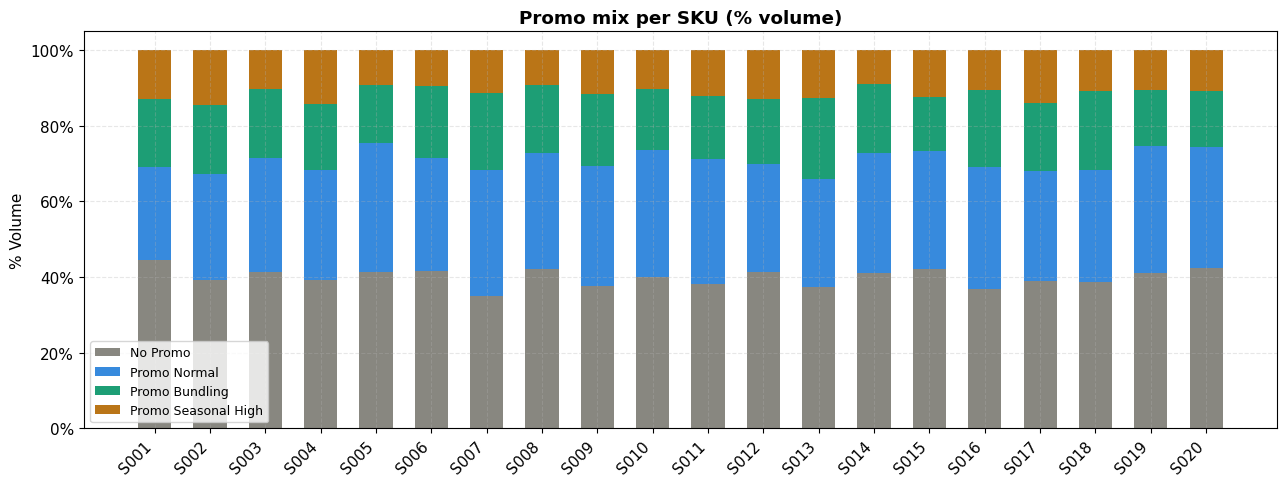

✓ EDA plots saved


In [ ]:
np.random.seed(42)

sku_meta = {
    'S001': {'name': 'Richeese Wafer Keju 50g',          'category': 'Wafer',          'brand': 'Richeese', 'normal_price': 6100},
    'S002': {'name': 'Richoco Wafer Cokelat 50g',         'category': 'Wafer',          'brand': 'Richoco',  'normal_price': 6100},
    'S003': {'name': 'Richeese Wafer Keju 10g Renceng',   'category': 'Wafer',          'brand': 'Richeese', 'normal_price': 10000},
    'S004': {'name': 'Richoco Wafer Cokelat 10g Renceng', 'category': 'Wafer',          'brand': 'Richoco',  'normal_price': 10000},
    'S005': {'name': 'Nextar Brownies Pie 40g',           'category': 'Kue/Pie',        'brand': 'Nextar',   'normal_price': 8000},
    'S006': {'name': 'Nextar Nastar Pie 30g',             'category': 'Kue/Pie',        'brand': 'Nextar',   'normal_price': 7000},
    'S007': {'name': 'Richeese Siip Keju 20g',            'category': 'Extruded Snack', 'brand': 'Richeese', 'normal_price': 3000},
    'S008': {'name': 'Richoco Ahh! Extruded 15g',         'category': 'Extruded Snack', 'brand': 'Richoco',  'normal_price': 4500},
    'S009': {'name': 'Richeese Mi Instan Keju Pedas',     'category': 'Mi Instan',      'brand': 'Richeese', 'normal_price': 3500},
    'S010': {'name': 'Richeese Mi Instan Ramen Keju',     'category': 'Mi Instan',      'brand': 'Richeese', 'normal_price': 4000},
    'S011': {'name': 'Nabati Biskuit Rasa Kelapa',        'category': 'Biskuit',        'brand': 'Richeese', 'normal_price': 5000},
    'S012': {'name': 'Nabati Biskuit Rasa Cokelat',       'category': 'Biskuit',        'brand': 'Richoco',  'normal_price': 5000},
    'S013': {'name': 'Nabati Drinko Richeese 150ml',      'category': 'Minuman',        'brand': 'Richeese', 'normal_price': 4000},
    'S014': {'name': 'Nabati Drinko Richoco 150ml',       'category': 'Minuman',        'brand': 'Richoco',  'normal_price': 4000},
    'S015': {'name': 'Richeese Wafer Pink Lava 50g',      'category': 'Wafer',          'brand': 'Richeese', 'normal_price': 5500},
    'S016': {'name': 'Richoco Wafer Hazelnut 50g',        'category': 'Wafer',          'brand': 'Richoco',  'normal_price': 6000},
    'S017': {'name': 'Nextar Choco Delight 40g',          'category': 'Kue/Pie',        'brand': 'Nextar',   'normal_price': 7000},
    'S018': {'name': 'Nextar Pineapple Pie 30g',          'category': 'Kue/Pie',        'brand': 'Nextar',   'normal_price': 7000},
    'S019': {'name': 'Richeese Siip Jagung Bakar 20g',    'category': 'Extruded Snack', 'brand': 'Richeese', 'normal_price': 3000},
    'S020': {'name': 'Richeese Mi Instan Goreng',         'category': 'Mi Instan',      'brand': 'Richeese', 'normal_price': 3500},
}

discount_map = {
    'No Promo':            0.00,
    'Promo Normal':        0.075,
    'Promo Bundling':      0.05,
    'Promo Seasonal High': 0.25,
}

promo_weights = {
    'No Promo':            0.448,
    'Promo Normal':        0.297,
    'Promo Bundling':      0.157,
    'Promo Seasonal High': 0.098,
}

monthly_index = {5: 0.792, 6: 0.887, 7: 0.944, 8: 1.055, 9: 1.322}
baseline_qty  = {
    'S001': 910, 'S002': 426, 'S003': 425, 'S004': 428,
    'S005': 428, 'S006': 423, 'S007': 431, 'S008': 422,
    'S009': 423, 'S010': 424, 'S011': 424, 'S012': 420,
    'S013': 912, 'S014': 432, 'S015': 428, 'S016': 430,
    'S017': 422, 'S018': 427, 'S019': 422, 'S020': 435,
}
branches     = ['Jakarta', 'Bandung', 'Surabaya', 'Semarang']
branch_scale = {'Jakarta': 1.0, 'Bandung': 0.40, 'Surabaya': 0.75, 'Semarang': 0.28}

cannibalization_truth = {
    ('S001', 'S002'): -0.25, ('S002', 'S001'): -0.20,
    ('S001', 'S015'): -0.15, ('S015', 'S001'): -0.15,
    ('S003', 'S004'): -0.20, ('S004', 'S003'): -0.18,
    ('S007', 'S008'): -0.22, ('S008', 'S007'): -0.18,
    ('S019', 'S007'): -0.20, ('S007', 'S019'): -0.20,
    ('S009', 'S010'): -0.18, ('S010', 'S009'): -0.15,
    ('S009', 'S020'): -0.15, ('S020', 'S009'): -0.12,
    ('S011', 'S012'): -0.20, ('S012', 'S011'): -0.18,
    ('S013', 'S014'): -0.30, ('S014', 'S013'): -0.25,
    ('S005', 'S006'):  0.10, ('S006', 'S005'):  0.10,
}

dates = pd.date_range('2025-05-01', '2025-09-30', freq='D')
rows  = []

for date in dates:
    month      = date.month
    season_idx = monthly_index[month]
    for branch in branches:
        bscale     = branch_scale[branch]
        sku_promos = {
            sku: np.random.choice(list(promo_weights.keys()), p=list(promo_weights.values()))
            for sku in sku_meta.keys()
        }
        sku_prices = {}
        for sku, promo in sku_promos.items():
            normal = sku_meta[sku]['normal_price']
            disc   = 0.50 if (sku == 'S013' and promo == 'Promo Bundling') else discount_map[promo]
            sku_prices[sku] = normal * (1 - disc)

        for sku in sku_meta.keys():
            base  = baseline_qty[sku] * season_idx * bscale
            promo = sku_promos[sku]
            own_boost = {
                'No Promo':            1.0,
                'Promo Normal':        1.15,
                'Promo Bundling':      1.40 if sku in ['S001','S013'] else 1.25,
                'Promo Seasonal High': 1.35,
            }[promo]

            cannibal_effect = 1.0
            for (sku_a, sku_b), elast in cannibalization_truth.items():
                if sku_b == sku and sku_promos[sku_a] != 'No Promo':
                    cannibal_effect += elast * 0.5

            noise = np.random.normal(1.0, 0.20)
            qty   = max(1, int(base * own_boost * cannibal_effect * noise))
            disc  = 0.50 if (sku == 'S013' and promo == 'Promo Bundling') else discount_map[promo]

            rows.append({
                'Date'              : date.date(),
                'Month'             : month,
                'Branch'            : branch,
                'SKU_ID'            : sku,
                'SKU_Name'          : sku_meta[sku]['name'],
                'SKU_Category'      : sku_meta[sku]['category'],
                'Brand'             : sku_meta[sku]['brand'],
                'NormalPrice'       : sku_meta[sku]['normal_price'],
                'DiscountedPrice'   : sku_prices[sku],
                'DiscountPercentage': round(disc, 3),
                'Promo_Category'    : promo,
                'Qty'               : qty,
                'Revenue'           : qty * sku_prices[sku],
            })

sim_df = pd.DataFrame(rows)
sim_df['Date'] = pd.to_datetime(sim_df['Date'])
sim_df.to_csv(OUTPUT_DIR + 'simulated_dataset.csv', index=False)

print(f"✅ Dataset generated")
print(f"   Shape      : {sim_df.shape}")
print(f"   Date range : {sim_df['Date'].min().date()} → {sim_df['Date'].max().date()}")
print(f"   Unique SKU : {sim_df['SKU_ID'].nunique()}")
print(f"\nPromo distribution:")
print((sim_df['Promo_Category'].value_counts(normalize=True)*100).round(1))
print(f"\nSample SKU_Name:")
print(sim_df[['SKU_ID','SKU_Name']].drop_duplicates().sort_values('SKU_ID').to_string(index=False))

In [2]:
sim_df['month_num'] = sim_df['Month'] - sim_df['Month'].min()
sim_df['log_qty']   = np.log(sim_df['Qty'] + 1)

# Pivot ke wide format
qty_wide   = sim_df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='log_qty')
disc_wide  = sim_df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='DiscountPercentage')
meta_wide  = sim_df.groupby(['Date','Branch'])[['month_num']].first()

sku_cat   = sim_df.groupby('SKU_ID')['SKU_Category'].first().to_dict()
sku_brand = sim_df.groupby('SKU_ID')['Brand'].first().to_dict()
sku_name  = {s: s for s in sku_cat.keys()}  # bisa diganti nama SKU asli

print(f'Shape qty_wide  : {qty_wide.shape}')
print(f'Shape disc_wide : {disc_wide.shape}')
print(f'\nSample qty_wide (5 baris pertama):')
display(qty_wide.head())


NameError: name 'sim_df' is not defined

In [5]:
results = []

for cat in sorted(sim_df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2:
        continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            reg_df = pd.DataFrame({
                'log_qty_B' : qty_wide[sku_b],
                'disc_pct_A': disc_wide[sku_a],
                'disc_pct_B': disc_wide[sku_b],
            }).join(meta_wide).reset_index().dropna()

            if len(reg_df) < 30:
                continue

            model = smf.ols(
                'log_qty_B ~ disc_pct_A + disc_pct_B + month_num + C(Branch)',
                data=reg_df
            ).fit()

            coef = model.params.get('disc_pct_A')
            pval = model.pvalues.get('disc_pct_A')
            if coef is None:
                continue

            results.append({
                'SKU_Category': cat,
                'SKU_A'       : sku_a,
                'Brand_A'     : sku_brand[sku_a],
                'SKU_B'       : sku_b,
                'Brand_B'     : sku_brand[sku_b],
                'coef_disc_A' : round(coef, 4),
                'p_value'     : round(pval, 4),
                'r_squared'   : round(model.rsquared, 4),
                'n_obs'       : len(reg_df),
            })
        except:
            continue

results_df = pd.DataFrame(results)

def verdict(row):
    if row['p_value'] >= 0.05:    return 'Tidak Signifikan'
    elif row['coef_disc_A'] < 0:  return 'CANNIBALIZATION'
    else:                          return 'KOMPLEMEN'

results_df['verdict'] = results_df.apply(verdict, axis=1)

print('=== VERDICT SUMMARY ===')
print(results_df['verdict'].value_counts())

print('\n=== CANNIBALIZATION (p<0.05, coef negatif) ===')
c = results_df[results_df['verdict']=='CANNIBALIZATION'].sort_values('coef_disc_A')
display(c[['SKU_Category','SKU_A','Brand_A','SKU_B','Brand_B','coef_disc_A','p_value','r_squared','n_obs']])

print('\n=== KOMPLEMEN (p<0.05, coef positif) ===')
k = results_df[results_df['verdict']=='KOMPLEMEN'].sort_values('coef_disc_A', ascending=False)
display(k[['SKU_Category','SKU_A','Brand_A','SKU_B','Brand_B','coef_disc_A','p_value','r_squared','n_obs']])

results_df.to_csv(OUTPUT_DIR + 'cannibalization_results.csv', index=False)
print('\n✓ Saved: cannibalization_results.csv')


=== VERDICT SUMMARY ===
verdict
Tidak Signifikan    37
CANNIBALIZATION     18
KOMPLEMEN            3
Name: count, dtype: int64

=== CANNIBALIZATION (p<0.05, coef negatif) ===


,SKU_Category,SKU_A,Brand_A,SKU_B,Brand_B,coef_disc_A,p_value,r_squared,n_obs
27,Minuman,S014,Richoco,S013,Richeese,-0.8724,0.0000,0.8377,612
40,Wafer,S003,Richeese,S004,Richoco,-0.7876,0.0000,0.8657,612
2,Extruded Snack,S007,Richeese,S008,Richoco,-0.7444,0.0000,0.8484,612
20,Mi Instan,S009,Richeese,S010,Richeese,-0.6752,0.0000,0.8605,612
28,Wafer,S001,Richeese,S002,Richoco,-0.6555,0.0000,0.8411,612
22,Mi Instan,S010,Richeese,S009,Richeese,-0.5687,0.0000,0.8569,612
1,Biskuit,S012,Richoco,S011,Richeese,-0.5424,0.0000,0.8501,612
31,Wafer,S001,Richeese,S015,Richeese,-0.5336,0.0000,0.8616,612
45,Wafer,S004,Richoco,S003,Richeese,-0.5063,0.0001,0.8300,612
0,Biskuit,S011,Richeese,S012,Richoco,-0.4980,0.0000,0.8715,612



=== KOMPLEMEN (p<0.05, coef positif) ===


,SKU_Category,SKU_A,Brand_A,SKU_B,Brand_B,coef_disc_A,p_value,r_squared,n_obs
8,Kue/Pie,S005,Nextar,S006,Nextar,0.3234,0.0185,0.8461,612
18,Kue/Pie,S018,Nextar,S006,Nextar,0.2857,0.0270,0.8459,612
36,Wafer,S002,Richoco,S015,Richeese,0.2417,0.0439,0.8583,612



✓ Saved: cannibalization_results.csv


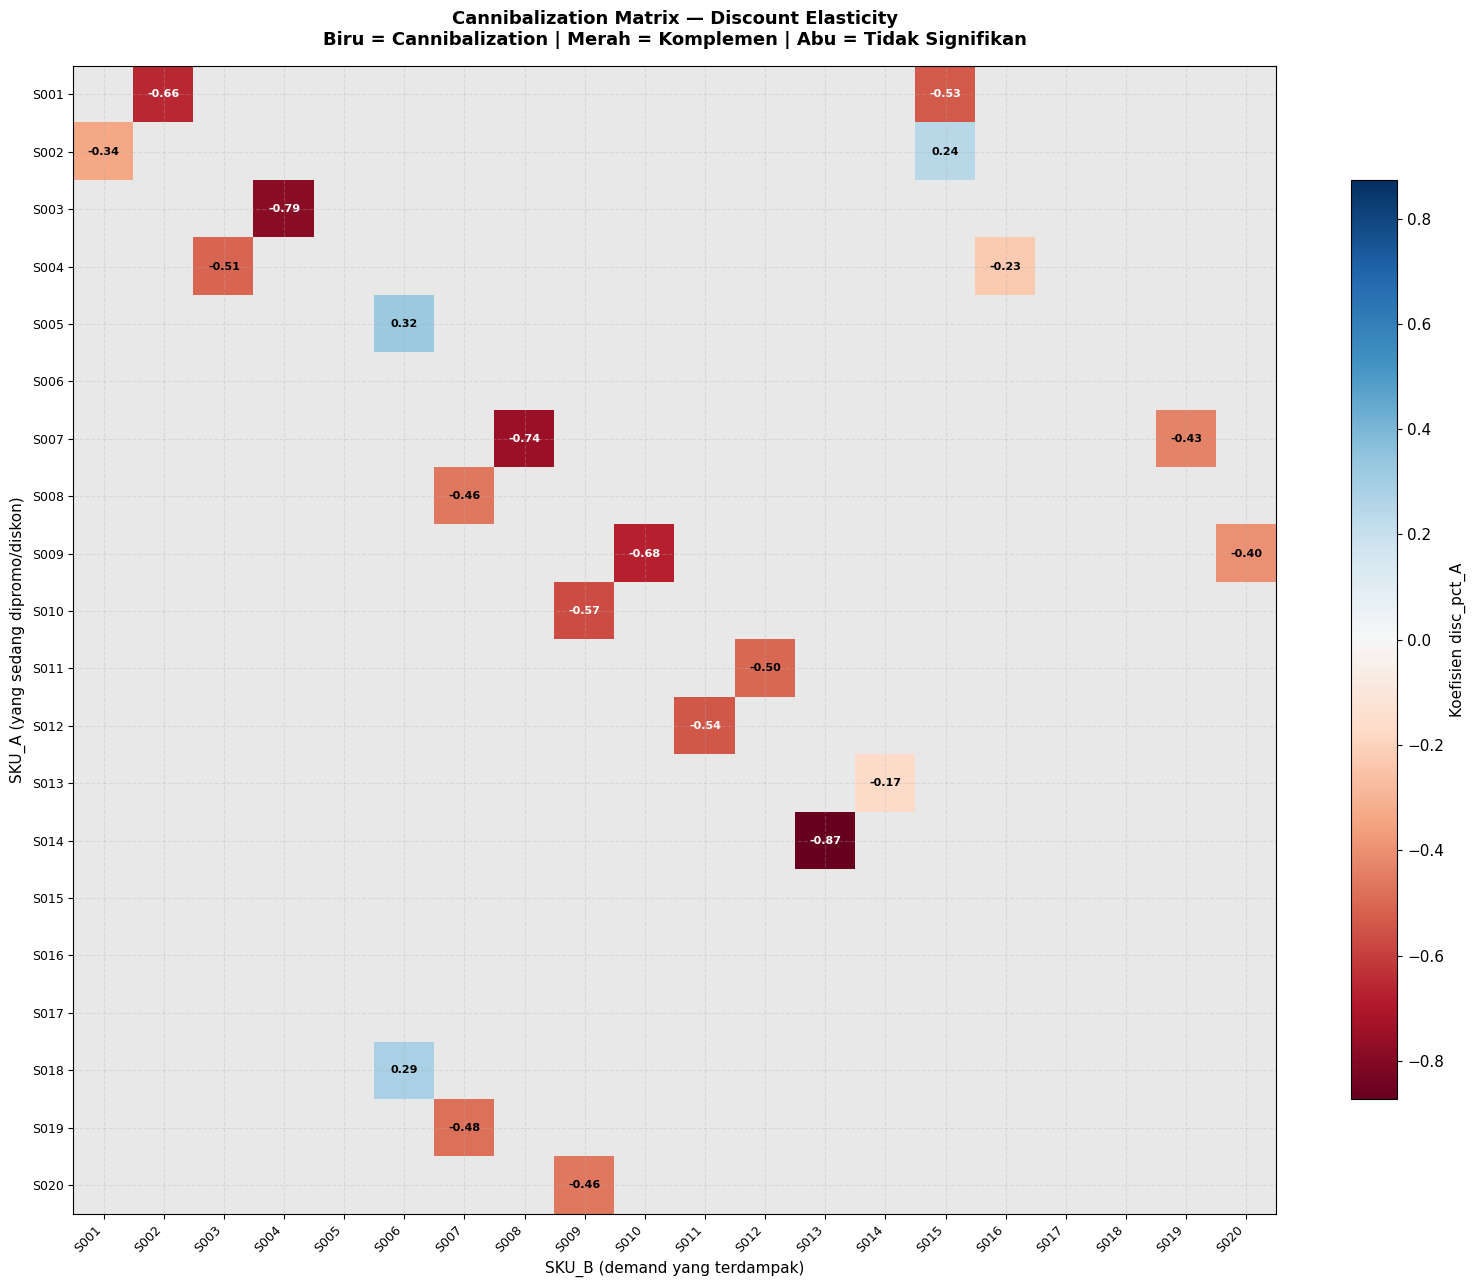

✓ Saved: 03_cannibalization_matrix.png


In [6]:
all_skus = sorted(set(results_df['SKU_A'].unique()) | set(results_df['SKU_B'].unique()))
matrix   = pd.DataFrame(np.nan, index=all_skus, columns=all_skus)

for _, row in results_df.iterrows():
    if row['verdict'] != 'Tidak Signifikan':
        matrix.loc[row['SKU_A'], row['SKU_B']] = row['coef_disc_A']

fig, ax = plt.subplots(figsize=(16, 13))
cmap = plt.cm.RdBu
cmap.set_bad(color='#E8E8E8')

vals        = matrix.values.astype(float)
finite_vals = vals[np.isfinite(vals)]
vmax        = max(abs(finite_vals).max(), 0.5) if len(finite_vals) > 0 else 1.0

im = ax.imshow(vals, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(all_skus)))
ax.set_yticks(range(len(all_skus)))
ax.set_xticklabels(all_skus, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_skus, fontsize=9)

for i, sku_a in enumerate(all_skus):
    for j, sku_b in enumerate(all_skus):
        val = matrix.loc[sku_a, sku_b]
        if not np.isnan(val):
            color = 'white' if abs(val) > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('SKU_B (demand yang terdampak)', fontsize=11)
ax.set_ylabel('SKU_A (yang sedang dipromo/diskon)', fontsize=11)
ax.set_title(
    'Cannibalization Matrix — Discount Elasticity\n'
    'Biru = Cannibalization | Merah = Komplemen | Abu = Tidak Signifikan',
    fontsize=13, fontweight='bold', pad=15
)
plt.colorbar(im, ax=ax, label='Koefisien disc_pct_A', shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '03_cannibalization_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 03_cannibalization_matrix.png')


,SKU_Category,SKU_A,SKU_B,coef_disc_A,avg_daily_rev_B,pct_qty_change,daily_rev_impact
15,Wafer,S003,S004,-0.7876,2564820.0,-7.88,-202005.0
11,Minuman,S014,S013,-0.8724,1966945.0,-8.72,-171596.0
16,Wafer,S004,S003,-0.5063,2600255.0,-5.06,-131651.0
14,Wafer,S002,S001,-0.3366,2919231.0,-3.37,-98261.0
12,Wafer,S001,S002,-0.6555,1398380.0,-6.55,-91664.0
2,Extruded Snack,S007,S008,-0.7444,1112726.0,-7.44,-82831.0
13,Wafer,S001,S015,-0.5336,1423782.0,-5.34,-75973.0
6,Mi Instan,S009,S010,-0.6752,1035751.0,-6.75,-69934.0
1,Biskuit,S012,S011,-0.5424,1278140.0,-5.42,-69326.0
0,Biskuit,S011,S012,-0.4980,1250655.0,-4.98,-62283.0


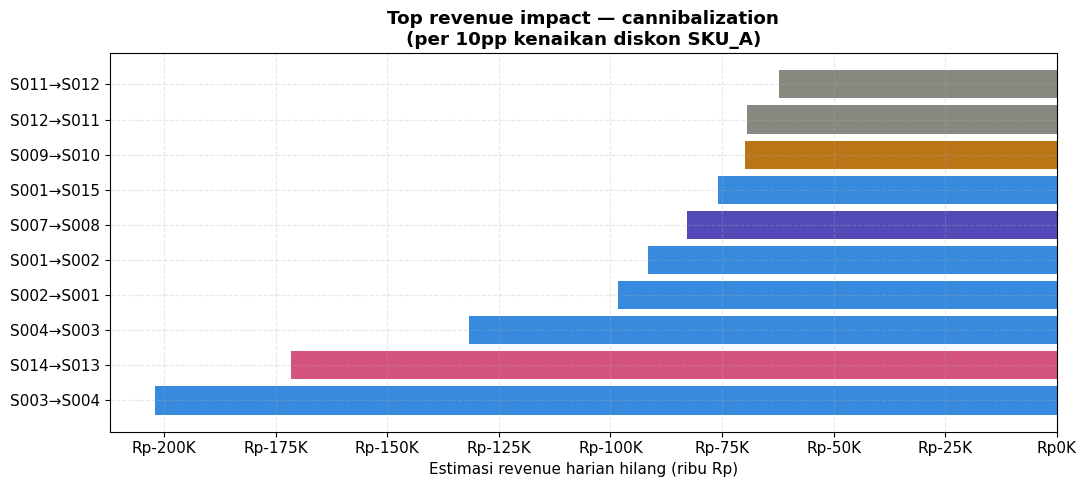

✓ Saved: revenue_impact.csv


In [7]:
# Hitung avg daily revenue per SKU per branch
daily_rev = sim_df.groupby(['SKU_ID','Branch'])['Revenue'].mean().reset_index()
daily_rev.columns = ['SKU_ID','Branch','avg_daily_revenue']

cannibal_df = results_df[results_df['verdict'] == 'CANNIBALIZATION'].copy()

# Estimasi: jika disc_pct_A naik 10pp (misal dari 0% ke 10%), revenue B turun sebesar?
impact_rows = []
for _, row in cannibal_df.iterrows():
    rev_b = daily_rev[daily_rev['SKU_ID'] == row['SKU_B']]['avg_daily_revenue'].mean()
    # pct change qty_B = coef * delta_disc_A
    # kita simulasikan delta_disc = 0.10 (10 percentage point)
    delta_disc    = 0.10
    pct_change    = row['coef_disc_A'] * delta_disc  # dalam log unit ≈ pct change
    rev_impact    = rev_b * pct_change  # negatif = revenue hilang
    impact_rows.append({
        'SKU_Category'    : row['SKU_Category'],
        'SKU_A'           : row['SKU_A'],
        'SKU_B'           : row['SKU_B'],
        'coef_disc_A'     : row['coef_disc_A'],
        'avg_daily_rev_B' : round(rev_b, 0),
        'pct_qty_change'  : round(pct_change * 100, 2),
        'daily_rev_impact': round(rev_impact, 0),
    })

impact_df = pd.DataFrame(impact_rows).sort_values('daily_rev_impact')
display(impact_df)

# Bar chart top 10 revenue impact
top10 = impact_df.nsmallest(10, 'daily_rev_impact')
fig, ax = plt.subplots(figsize=(11, 5))
colors  = [CAT_COLOR.get(c, '#999') for c in top10['SKU_Category']]
labels  = [f"{r['SKU_A']}→{r['SKU_B']}" for _, r in top10.iterrows()]
ax.barh(labels, top10['daily_rev_impact']/1000, color=colors)
ax.set_xlabel('Estimasi revenue harian hilang (ribu Rp)')
ax.set_title('Top revenue impact — cannibalization\n(per 10pp kenaikan diskon SKU_A)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rp{x:.0f}K'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '04_revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()

impact_df.to_csv(OUTPUT_DIR + 'revenue_impact.csv', index=False)
print('✓ Saved: revenue_impact.csv')


In [8]:
print('=' * 65)
print('RINGKASAN HASIL CANNIBALIZATION ANALYSIS')
print('=' * 65)

total     = len(results_df)
n_cannibal = (results_df['verdict'] == 'CANNIBALIZATION').sum()
n_komplemen= (results_df['verdict'] == 'KOMPLEMEN').sum()
n_insig    = (results_df['verdict'] == 'Tidak Signifikan').sum()

print(f'Total pasangan dianalisis : {total}')
print(f'  Cannibalization (p<0.05): {n_cannibal} ({n_cannibal/total*100:.1f}%)')
print(f'  Komplemen (p<0.05)      : {n_komplemen} ({n_komplemen/total*100:.1f}%)')
print(f'  Tidak Signifikan        : {n_insig} ({n_insig/total*100:.1f}%)')

print('\n--- Cannibalization per Kategori ---')
print(results_df[results_df['verdict']=='CANNIBALIZATION']
      .groupby('SKU_Category').size().rename('n_pairs'))

print('\n--- Pasangan dengan dampak revenue terbesar ---')
display(impact_df.nsmallest(5, 'daily_rev_impact')[[
    'SKU_Category','SKU_A','SKU_B','pct_qty_change','daily_rev_impact'
]])

print('\n--- Rekomendasi ---')
recs = [
    ('HIGH',   'Monitor diskon S013 (Minuman Richeese) — cannibalization terkuat terhadap S014'),
    ('HIGH',   'Hindari promo bersamaan untuk pasangan cannibalization tinggi dalam kategori yang sama'),
    ('MEDIUM', 'Pasangan komplemen bisa dijadikan bundling strategy — mereka saling mendorong'),
    ('INFO',   'Dataset ini adalah simulasi — validasi dengan data transaksi asli yang punya variasi promo per SKU'),
]
for sev, msg in recs:
    print(f'  [{sev}] {msg}')

print('\n✅ Analysis selesai. Output tersimpan di:', OUTPUT_DIR)


RINGKASAN HASIL CANNIBALIZATION ANALYSIS
Total pasangan dianalisis : 58
  Cannibalization (p<0.05): 18 (31.0%)
  Komplemen (p<0.05)      : 3 (5.2%)
  Tidak Signifikan        : 37 (63.8%)

--- Cannibalization per Kategori ---
SKU_Category
Biskuit           2
Extruded Snack    4
Mi Instan         4
Minuman           2
Wafer             6
Name: n_pairs, dtype: int64

--- Pasangan dengan dampak revenue terbesar ---


,SKU_Category,SKU_A,SKU_B,pct_qty_change,daily_rev_impact
15,Wafer,S003,S004,-7.88,-202005.0
11,Minuman,S014,S013,-8.72,-171596.0
16,Wafer,S004,S003,-5.06,-131651.0
14,Wafer,S002,S001,-3.37,-98261.0
12,Wafer,S001,S002,-6.55,-91664.0



--- Rekomendasi ---
  [HIGH] Monitor diskon S013 (Minuman Richeese) — cannibalization terkuat terhadap S014
  [HIGH] Hindari promo bersamaan untuk pasangan cannibalization tinggi dalam kategori yang sama
  [MEDIUM] Pasangan komplemen bisa dijadikan bundling strategy — mereka saling mendorong
  [INFO] Dataset ini adalah simulasi — validasi dengan data transaksi asli yang punya variasi promo per SKU

✅ Analysis selesai. Output tersimpan di: cannibalization_output/
